In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'YOUR_USERNAME'
os.environ['KAGGLE_KEY'] = 'YOUR_KEY'

In [ ]:
#!pip install kaggle

In [2]:
#https://www.kaggle.com/datasets/programmer3/undergraduate-employability-dataset?utm_source=chatgpt.com  {dataset link}

#Kaggle CLI used here
#!/bin/bash
!kaggle datasets download -d programmer3/undergraduate-employability-dataset

Dataset URL: https://www.kaggle.com/datasets/programmer3/undergraduate-employability-dataset
License(s): CC0-1.0
100% 47.0k/47.0k [00:00<00:00, 50.2MB/s]



In [3]:
!unzip undergraduate-employability-dataset.zip

Archive:  undergraduate-employability-dataset.zip
  inflating: UECD_1200_dataset.csv   


In [4]:
#Import Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [5]:
#Load Dataset
data = pd.read_csv("UECD_1200_dataset.csv")

data.head()

,GPA,Core_Subject_Score,Academic_Consistency,Research_Participation,Programming_Skill,Domain_Knowledge,Tool_Proficiency,Certification_Count,Internship_Count,Internship_Duration,...,Learning_Motivation,Career_Clarity,Market_Awareness,Higher_Study_Interest,Target_Industry_Code,Workshop_Participation,Online_Course_Hours,Networking_Activity,Learning_Path_Generation_Time,Employment_Competitiveness_Score
0,7.19,66.0,2.14,1.0,48.0,51.0,35.0,2.0,3.0,13.0,...,50.0,89.0,93.0,0.0,NaN,6.0,243.4,23.0,8.98,30.55
1,9.78,61.0,1.42,0.0,70.0,85.0,75.0,5.0,0.0,7.3,...,97.0,35.0,91.0,1.0,5.0,11.0,20.0,44.0,8.98,NaN
2,8.79,83.0,1.22,0.0,54.0,52.0,79.0,5.0,3.0,3.9,...,77.0,36.0,88.0,1.0,3.0,5.0,96.5,55.0,6.21,66.03
3,8.19,65.0,1.49,0.0,43.0,81.0,67.0,5.0,1.0,6.4,...,67.0,75.0,NaN,0.0,2.0,4.0,162.5,83.0,1.03,NaN
4,6.20,87.0,2.16,0.0,79.0,95.0,47.0,3.0,2.0,5.1,...,73.0,86.0,86.0,0.0,3.0,3.0,220.0,63.0,7.17,47.25


In [6]:
print("Shape of dataset:", data.shape)

Shape of dataset: (1200, 26)


In [7]:
print(data.columns)

Index(['GPA', 'Core_Subject_Score', 'Academic_Consistency',
       'Research_Participation', 'Programming_Skill', 'Domain_Knowledge',
       'Tool_Proficiency', 'Certification_Count', 'Internship_Count',
       'Internship_Duration', 'Industry_Relevance', 'Project_Experience',
       'Communication_Skill', 'Teamwork_Ability', 'Leadership_Potential',
       'Adaptability', 'Learning_Motivation', 'Career_Clarity',
       'Market_Awareness', 'Higher_Study_Interest', 'Target_Industry_Code',
       'Workshop_Participation', 'Online_Course_Hours', 'Networking_Activity',
       'Learning_Path_Generation_Time', 'Employment_Competitiveness_Score'],
      dtype='object')


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   GPA                               1164 non-null   float64
 1   Core_Subject_Score                1164 non-null   float64
 2   Academic_Consistency              1164 non-null   float64
 3   Research_Participation            1164 non-null   float64
 4   Programming_Skill                 1164 non-null   float64
 5   Domain_Knowledge                  1164 non-null   float64
 6   Tool_Proficiency                  1164 non-null   float64
 7   Certification_Count               1164 non-null   float64
 8   Internship_Count                  1164 non-null   float64
 9   Internship_Duration               1164 non-null   float64
 10  Industry_Relevance                1164 non-null   float64
 11  Project_Experience                1164 non-null   float64
 12  Commun

In [9]:
data.isnull().sum()

,0
GPA,36
Core_Subject_Score,36
Academic_Consistency,36
Research_Participation,36
Programming_Skill,36
Domain_Knowledge,36
Tool_Proficiency,36
Certification_Count,36
Internship_Count,36
Internship_Duration,36


In [10]:
data.describe()

,GPA,Core_Subject_Score,Academic_Consistency,Research_Participation,Programming_Skill,Domain_Knowledge,Tool_Proficiency,Certification_Count,Internship_Count,Internship_Duration,...,Learning_Motivation,Career_Clarity,Market_Awareness,Higher_Study_Interest,Target_Industry_Code,Workshop_Participation,Online_Course_Hours,Networking_Activity,Learning_Path_Generation_Time,Employment_Competitiveness_Score
count,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,...,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,620.000000
mean,7.750584,74.371134,1.494983,0.265464,68.997423,71.974227,64.268900,2.375430,2.064433,8.848969,...,73.768041,64.613402,66.878866,0.389175,4.122852,5.469072,124.414777,59.589347,6.245052,47.755145
std,1.319964,11.403099,0.576473,0.441770,17.299322,16.079051,20.023736,1.739466,1.403278,5.065535,...,14.324497,20.260344,19.053302,0.487773,1.984339,3.413328,73.549694,23.219609,3.324204,16.032071
min,5.520000,55.000000,0.500000,0.000000,40.000000,45.000000,30.000000,0.000000,0.000000,0.000000,...,50.000000,30.000000,35.000000,0.000000,1.000000,0.000000,0.200000,20.000000,0.520000,0.000000
25%,6.577500,65.000000,1.020000,0.000000,54.000000,58.000000,47.000000,1.000000,1.000000,4.600000,...,61.000000,47.000000,50.000000,0.000000,2.000000,3.000000,60.750000,40.000000,3.330000,36.067500
50%,7.800000,74.000000,1.500000,0.000000,68.000000,72.000000,63.000000,2.000000,2.000000,8.900000,...,73.000000,65.000000,68.000000,0.000000,4.000000,5.000000,124.400000,59.000000,6.220000,48.175000
75%,8.892500,84.000000,1.990000,1.000000,84.000000,86.000000,82.000000,4.000000,3.000000,13.100000,...,85.000000,83.000000,84.000000,1.000000,6.000000,8.000000,189.750000,80.000000,9.100000,58.482500
max,10.000000,94.000000,2.500000,1.000000,99.000000,99.000000,99.000000,5.000000,4.000000,18.000000,...,99.000000,99.000000,99.000000,1.000000,7.000000,11.000000,249.700000,99.000000,12.000000,100.000000


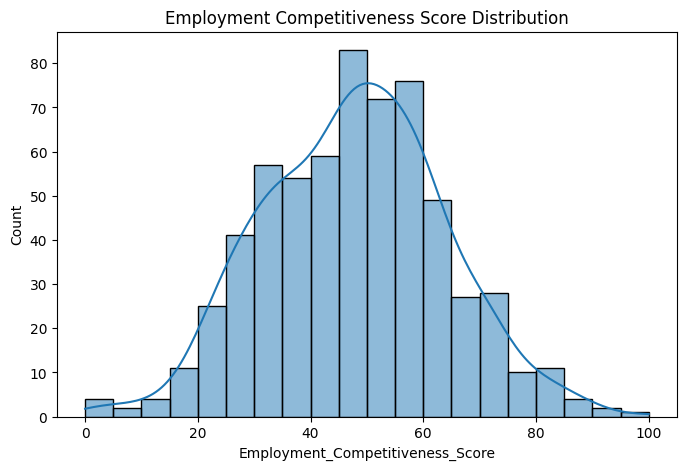

In [11]:
#target distribution
plt.figure(figsize=(8,5))

sns.histplot(data['Employment_Competitiveness_Score'], kde=True)

plt.title("Employment Competitiveness Score Distribution")

plt.show()

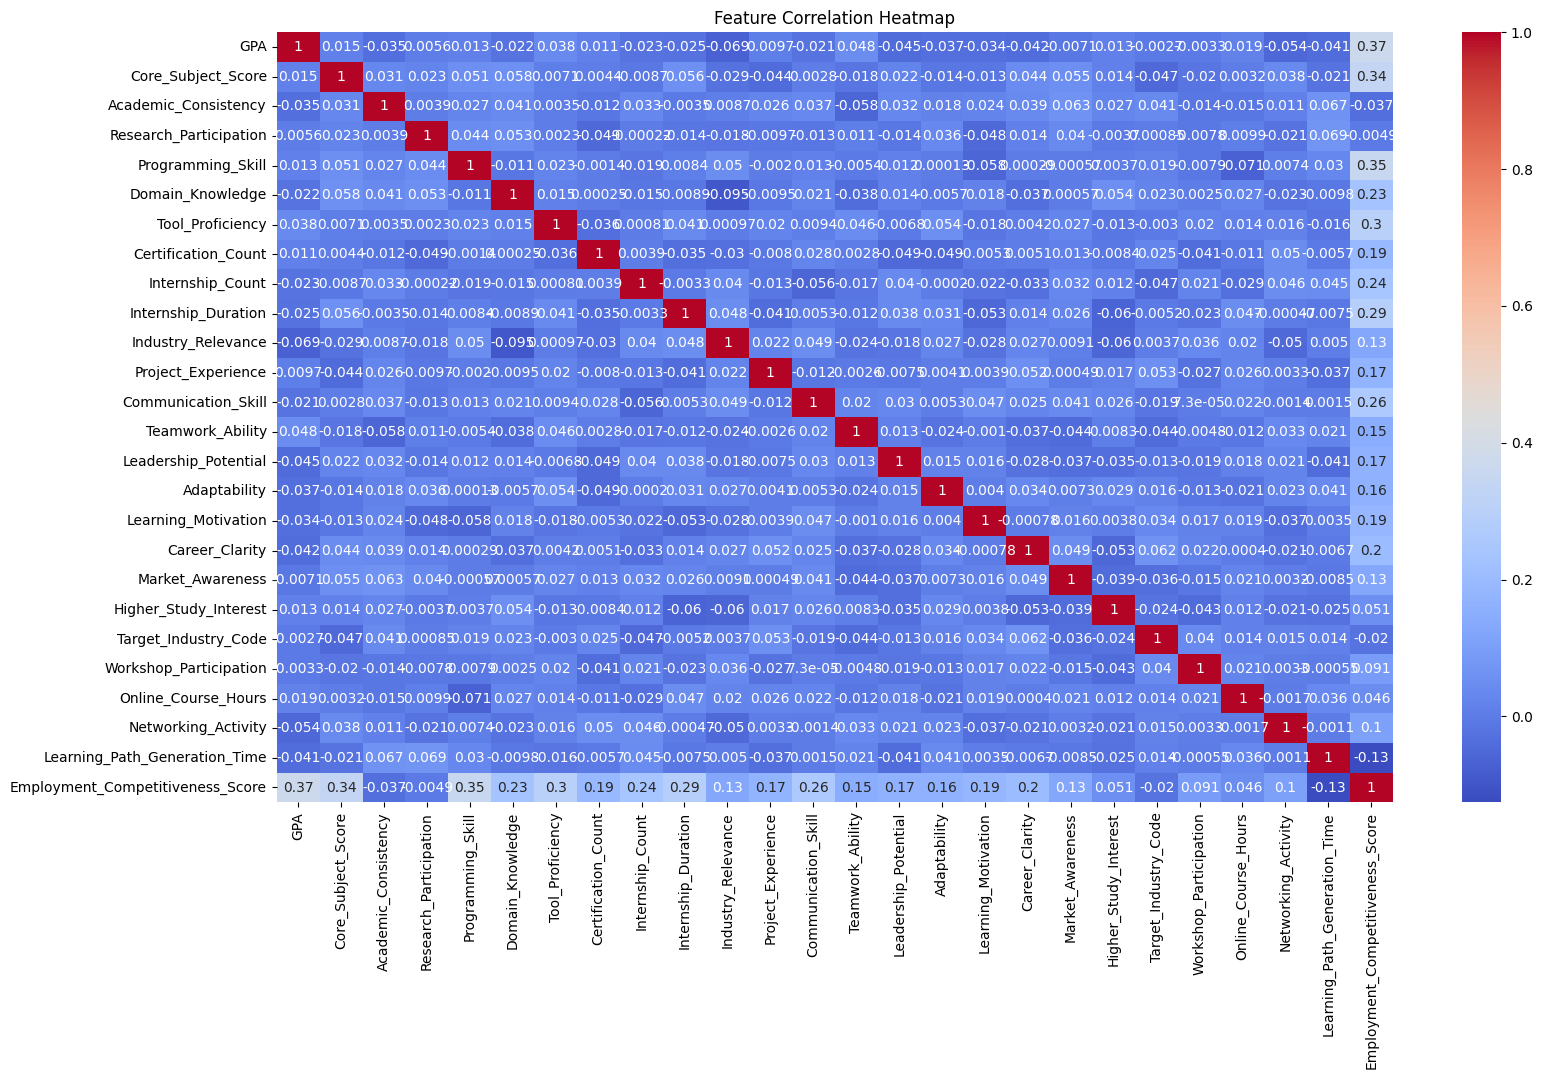

In [12]:
#correlation heatmap
plt.figure(figsize=(18,10))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

Remove rows with missing target and fill remaining missing values

In [13]:
data = data.dropna(subset=['Employment_Competitiveness_Score'])

In [14]:
data = data.fillna(data.median(numeric_only=True))

In [15]:
data.isnull().sum()

,0
GPA,0
Core_Subject_Score,0
Academic_Consistency,0
Research_Participation,0
Programming_Skill,0
Domain_Knowledge,0
Tool_Proficiency,0
Certification_Count,0
Internship_Count,0
Internship_Duration,0


In [16]:
print(data.shape)

(620, 26)


# Model Pipleine

classification label

In [17]:
data['Employable'] = (
    data['Employment_Competitiveness_Score'] >= 60
).astype(int)

In [18]:
#class distribution
data['Employable'].value_counts()

,count
Employable,
0,488
1,132


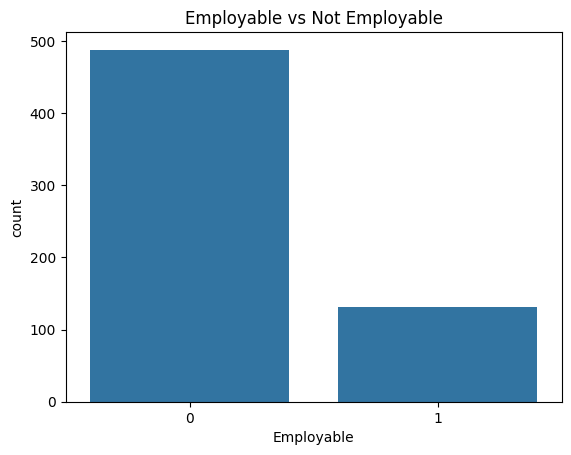

In [19]:
sns.countplot(x='Employable', data=data)

plt.title("Employable vs Not Employable")

plt.show()

In [ ]:
#!pip install xgboost

In [20]:
#import Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [21]:
X = data.drop(
    ['Employment_Competitiveness_Score', 'Employable'],
    axis=1
)

y = data['Employable']

In [22]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
#feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
#train Logistic regression
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [25]:
#evaluate logistic regression
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))

Accuracy: 0.967741935483871
Precision: 0.9583333333333334
Recall: 0.8846153846153846
F1 Score: 0.92
ROC AUC: 0.9372056514913658


In [26]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        98
           1       0.96      0.88      0.92        26

    accuracy                           0.97       124
   macro avg       0.96      0.94      0.95       124
weighted avg       0.97      0.97      0.97       124



In [27]:
#train Random forest(RF)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [28]:
#evaluate RF
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))

Accuracy: 0.8387096774193549
Precision: 0.875
Recall: 0.2692307692307692
F1 Score: 0.4117647058823529
ROC AUC: 0.629513343799058


In [29]:
#train XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [30]:
#evaluate XGBoost
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_pred_xgb))

Accuracy: 0.8629032258064516
Precision: 0.8461538461538461
Recall: 0.4230769230769231
F1 Score: 0.5641025641025641
ROC AUC: 0.7013343799058085


In [32]:
#to check data leakage
corr = data.corr(numeric_only=True)

print(corr['Employable'].sort_values(ascending=False))

Employable                          1.000000
Employment_Competitiveness_Score    0.704439
GPA                                 0.260143
Programming_Skill                   0.245421
Internship_Count                    0.223953
Tool_Proficiency                    0.223851
Internship_Duration                 0.209222
Communication_Skill                 0.189753
Core_Subject_Score                  0.178783
Career_Clarity                      0.169980
Certification_Count                 0.161706
Domain_Knowledge                    0.156657
Teamwork_Ability                    0.122778
Learning_Motivation                 0.116632
Market_Awareness                    0.110580
Project_Experience                  0.104479
Adaptability                        0.091913
Leadership_Potential                0.081860
Workshop_Participation              0.076864
Industry_Relevance                  0.065430
Networking_Activity                 0.036645
Research_Participation              0.016997
Online_Cou

In [33]:
#cross validation
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

new_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        solver='liblinear'
    ))
])

cv_scores = cross_val_score(
    new_pipeline,
    X,
    y,
    cv=5,
    scoring='f1'
)

print("Cross Validation F1 Scores:")
print(cv_scores)

print("\nMean f1 Score:")
print(cv_scores.mean())

Cross Validation F1 Scores:
[0.83870968 0.89655172 0.88888889 0.94736842 0.84745763]

Mean f1 Score:
0.88379526772349


In [34]:
new_pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    solver='liblinear'))])

In [35]:
#feature important analysis
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': new_pipeline.named_steps[
        'model'
    ].coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

                          Feature  Coefficient
0                             GPA     2.456389
4               Programming_Skill     1.952683
8                Internship_Count     1.552821
6                Tool_Proficiency     1.487023
5                Domain_Knowledge     1.460390
1              Core_Subject_Score     1.389720
7             Certification_Count     1.349449
17                 Career_Clarity     1.341269
12            Communication_Skill     1.301055
9             Internship_Duration     1.222479
13               Teamwork_Ability     1.213095
16            Learning_Motivation     1.146198
11             Project_Experience     1.122233
15                   Adaptability     1.013224
18               Market_Awareness     1.012881
14           Leadership_Potential     0.801482
23            Networking_Activity     0.626649
21         Workshop_Participation     0.507118
10             Industry_Relevance     0.462823
22            Online_Course_Hours     0.224252
20           

/tmp/ipykernel_1018/728240570.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


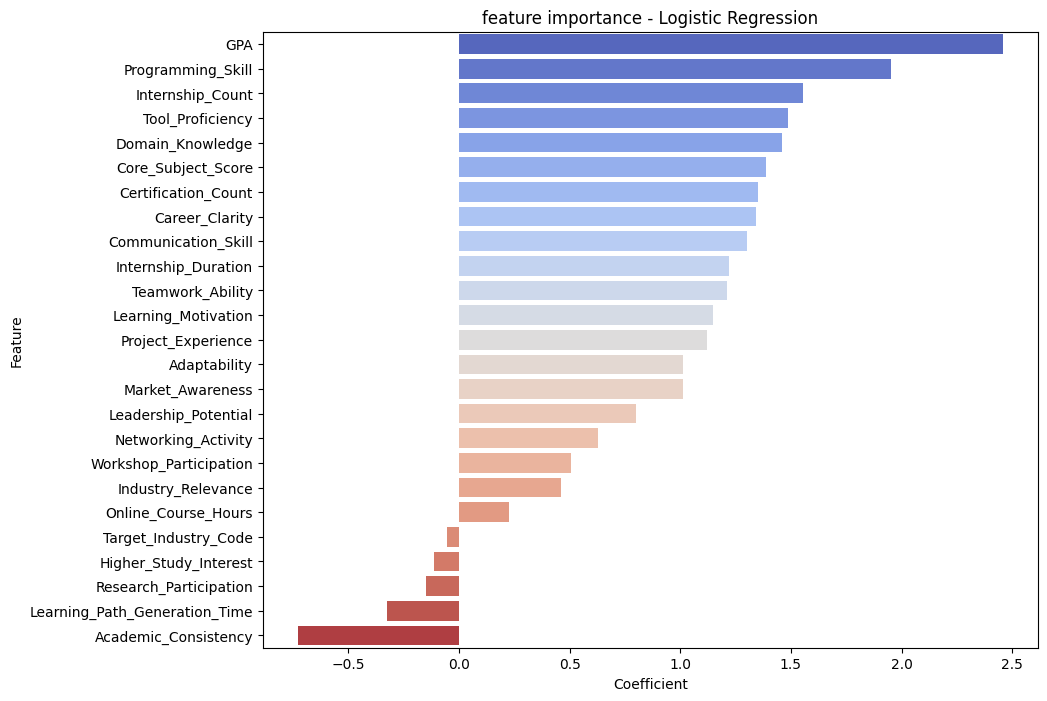

In [37]:
#visualize the feature
plt.figure(figsize=(10,8))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance,
    palette="coolwarm"
)

plt.title("feature importance - Logistic Regression")

plt.show()

In [38]:
y_pred = new_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, new_pipeline.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96        98
           1       0.81      0.96      0.88        26

    accuracy                           0.94       124
   macro avg       0.90      0.95      0.92       124
weighted avg       0.95      0.94      0.95       124

ROC AUC: 0.9952904238618525


#Save the Model

In [39]:
import joblib

joblib.dump(
    new_pipeline,
    'employability_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [40]:
#download from colab
from google.colab import files

files.download('employability_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>